### Import des librairies

In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

### CHARGEMENT DES DONNEES

In [299]:
#liste des feuilles dans le fichier excel
sheets = pd.ExcelFile("../Data/pneumodetect 1.xlsx").sheet_names
sheets

['statut tabac-diag',
 'EGFR +',
 'ROS1 +',
 'ALK +',
 'TP53',
 'Rearrangement ROS',
 'Rearrangement ALK',
 'BRAF +']

In [300]:
df_patients_statut = pd.read_excel("../Data/pneumodetect 1.xlsx", sheet_name=sheets[0])
df_mut_EGFR = pd.read_excel("../Data/pneumodetect 1.xlsx", sheet_name=sheets[1])
df_mut_Ros1 = pd.read_excel("../Data/pneumodetect 1.xlsx", sheet_name=sheets[2])
df_mut_alk = pd.read_excel("../Data/pneumodetect 1.xlsx", sheet_name=sheets[3])
df_mut_tp54 = pd.read_excel("../Data/pneumodetect 1.xlsx", sheet_name=sheets[4])
df_mut_RROS = pd.read_excel("../Data/pneumodetect 1.xlsx", sheet_name=sheets[5])
df_mut_RALK = pd.read_excel("../Data/pneumodetect 1.xlsx", sheet_name=sheets[6])
df_mut_Braf = pd.read_excel("../Data/pneumodetect 1.xlsx", sheet_name=sheets[7])

dfs = [df_patients_statut, df_mut_EGFR, df_mut_Ros1, df_mut_alk, df_mut_tp54, df_mut_RROS, df_mut_RALK, df_mut_Braf]

In [301]:
for df in dfs:
    print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3057 entries, 0 to 3056
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   NIP             3057 non-null   int64 
 1   Patient fumeur  3057 non-null   object
 2   date de diag    3057 non-null   object
dtypes: int64(1), object(2)
memory usage: 71.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353 entries, 0 to 352
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   EGFR positif  353 non-null    int64
dtypes: int64(1)
memory usage: 2.9 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Ros1 positif  20 non-null     int64
dtypes: int64(1)
memory usage: 292.0 bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data 

In [302]:
for i in range(len(dfs)):
    dfs[i] = dfs[i].rename(columns={dfs[i].columns[0]: 'NIP'})

In [303]:
for df in dfs:
    columns = df.columns.tolist()
    df = df.rename(columns={columns[0]: 'NIP'})

In [304]:
len(df_patients_statut)

3057

In [305]:
df_patients_statut = df_patients_statut.rename(columns={'Patient':'statut'})
df_patients = df_patients_statut.copy()

# Define conditions for mutations
conditions = [
    df_patients['NIP'].isin(dfs[1]['NIP']),
    df_patients['NIP'].isin(dfs[2]['NIP']),
    df_patients['NIP'].isin(dfs[3]['NIP']),
    df_patients['NIP'].isin(dfs[4]['NIP']),
    df_patients['NIP'].isin(dfs[5]['NIP']),
    df_patients['NIP'].isin(dfs[6]['NIP']),
    df_patients['NIP'].isin(dfs[7]['NIP'])
]

# Define corresponding mutation labels
choices = ['EGFR', 'Ros1', 'ALK', 'TP53', 'RROS', 'RALK', 'BRAF']

# Assign mutation labels based on conditions
df_patients['mutation'] = np.select(conditions, choices, default=pd.NA)


In [306]:
# Supprimer la ligne à la position 1399 : utiliser l'index du DataFrame (pas les noms de colonnes)

df_patients = df_patients.drop(df_patients.index[1399]).copy()



In [307]:
df_patients['date de diag'] = pd.to_datetime(df_patients['date de diag'], errors='coerce')

In [308]:
df_patients

,NIP,Patient fumeur,date de diag,mutation
0,9486811,ancien fumeur,2016-09-12,<NA>
1,1616205,fumeur,2016-10-04,<NA>
2,1613196,ancien fumeur,2016-07-21,<NA>
3,1520329,fumeur,2015-10-22,BRAF
4,787831,ancien fumeur,2007-11-15,<NA>
...,...,...,...,...
3052,2407844,ancien fumeur,2024-04-18,BRAF
3053,2408729,fumeur,2024-05-07,TP53
3054,2413869,ancien fumeur,2024-07-24,TP53
3055,2416892,fumeur,2024-09-04,<NA>


### Patients ayant plusieurs mutations

In [309]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1️⃣ Chargement et préparation des données
# ------------------------------------------------------------


# Liste des noms correspondant à tes feuilles de mutations (même ordre que dfs[1:])
mutation_names = ["EGFR", "ROS1", "ALK", "TP53", "RROS", "RALK", "BRAF"]

# Harmonisation du format des NIP
df_patients_statut = df_patients.copy()
df_patients_statut["NIP"] = df_patients_statut["NIP"].astype(str).str.strip()

# ------------------------------------------------------------
# 2️⃣ Concaténation de toutes les mutations
# ------------------------------------------------------------
mutations_list = []

for df_mut, name in zip(dfs[1:], mutation_names):  # on saute dfs[0] si c’est le df des patients
    df_temp = df_mut[["NIP"]].copy()
    df_temp["mutation"] = name
    df_temp["NIP"] = df_temp["NIP"].astype(str).str.strip()
    mutations_list.append(df_temp)

df_all_mutations = pd.concat(mutations_list, ignore_index=True)

# ------------------------------------------------------------
# 3️⃣ Comptage du nombre de mutations par patient
# ------------------------------------------------------------
mut_counts = (
    df_all_mutations.groupby("NIP")
    .agg(
        nombre_mutations=("mutation", "nunique"),
        liste_mutations=("mutation", lambda x: ", ".join(sorted(x.unique())))
    )
    .reset_index()
)

# ------------------------------------------------------------
# 4️⃣ Fusion avec le DataFrame principal (statut tabagique)
# ------------------------------------------------------------
df_result = df_patients_statut.merge(mut_counts, on="NIP", how="left")

# Remplacer les valeurs manquantes (patients sans mutation)
df_result["nombre_mutations"] = df_result["nombre_mutations"].fillna(0).astype(int)
df_result["liste_mutations"] = df_result["liste_mutations"].fillna("Aucune")

# ------------------------------------------------------------
# 5️⃣ Filtrer les patients multi-mutés
# ------------------------------------------------------------
df_multi_mut = df_result[df_result["nombre_mutations"] > 1].copy()
df_multi_mut = df_multi_mut.sort_values("nombre_mutations", ascending=False)

# ------------------------------------------------------------
# 6️⃣ Contrôle qualité global
# ------------------------------------------------------------
nb_total = df_patients_statut["NIP"].nunique()
nb_mut_uniques = df_all_mutations["NIP"].nunique()
nb_multi_mut = len(df_multi_mut)
nb_non_mut = len(df_result[df_result["nombre_mutations"] == 0])
somme = nb_mut_uniques + nb_non_mut

print("🧭 CONTROLE QUALITÉ")
print(f"Total patients (df_patients_statut) : {nb_total}")
print(f"Patients mutés uniques : {nb_mut_uniques}")
print(f"Patients multi-mutés : {nb_multi_mut}")
print(f"Patients non mutés : {nb_non_mut}")
print(f"Somme (mutés uniques + non mutés) : {somme}")
if somme == nb_total:
    print("✅ Cohérence parfaite")
else:
    print("⚠️ Incohérence : vérifier les NIP ou doublons dans les fichiers de mutations.")

# ------------------------------------------------------------
# 7️⃣ Résultat final : patients multi-mutés
# ------------------------------------------------------------
print("\n📋 Aperçu des patients multi-mutés :")
df_multi_mut

# # ------------------------------------------------------------
# # 8️⃣ (Optionnel) Export Excel
# # ------------------------------------------------------------
# df_multi_mut.to_excel("patients_multi_mutations.xlsx", index=False)


🧭 CONTROLE QUALITÉ
Total patients (df_patients_statut) : 3056
Patients mutés uniques : 1244
Patients multi-mutés : 141
Patients non mutés : 1812
Somme (mutés uniques + non mutés) : 3056
✅ Cohérence parfaite

📋 Aperçu des patients multi-mutés :


,NIP,Patient fumeur,date de diag,mutation,nombre_mutations,liste_mutations
311,1821587,non fumeur,2018-12-06,EGFR,5,"ALK, EGFR, RALK, RROS, TP53"
1986,2304874,fumeur,2023-04-19,TP53,4,"BRAF, RALK, RROS, TP53"
1731,2015741,fumeur,2020-11-05,TP53,4,"BRAF, RALK, RROS, TP53"
124,2003225,ancien fumeur,2020-03-05,EGFR,3,"BRAF, EGFR, TP53"
2602,1806653,non fumeur,2021-02-10,EGFR,3,"EGFR, ROS1, TP53"
...,...,...,...,...,...,...
800,1608342,fumeur,2016-06-07,ALK,2,"ALK, BRAF"
779,1403083,non fumeur,2014-02-26,ALK,2,"ALK, RALK"
657,1503828,fumeur,2015-02-04,RROS,2,"RALK, RROS"
625,1306436,ancien fumeur,2013-04-17,ALK,2,"ALK, BRAF"


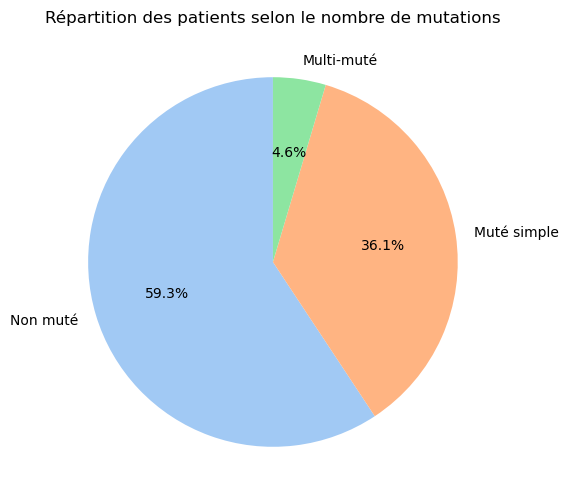

In [310]:
# Comptage par catégorie
cat_counts = df_result["nombre_mutations"].apply(lambda x: 
    "Non muté" if x == 0 else "Multi-muté" if x > 1 else "Muté simple"
).value_counts()

# Diagramme circulaire
plt.figure(figsize=(6,6))
plt.pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Répartition des patients selon le nombre de mutations")
plt.show()


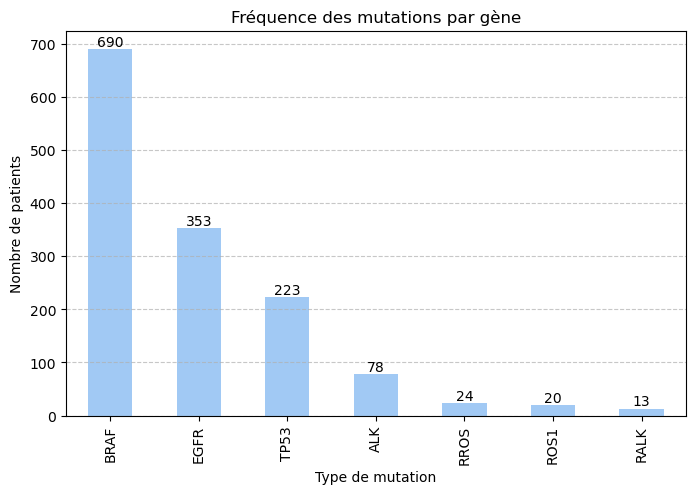

In [311]:
mutation_freq = df_all_mutations["mutation"].value_counts()

plt.figure(figsize=(8,5))
mutation_freq.plot(kind="bar")
plt.title("Fréquence des mutations par gène")
plt.xlabel("Type de mutation")
plt.ylabel("Nombre de patients")
plt.grid(axis="y", linestyle="--", alpha=0.7)
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.show()


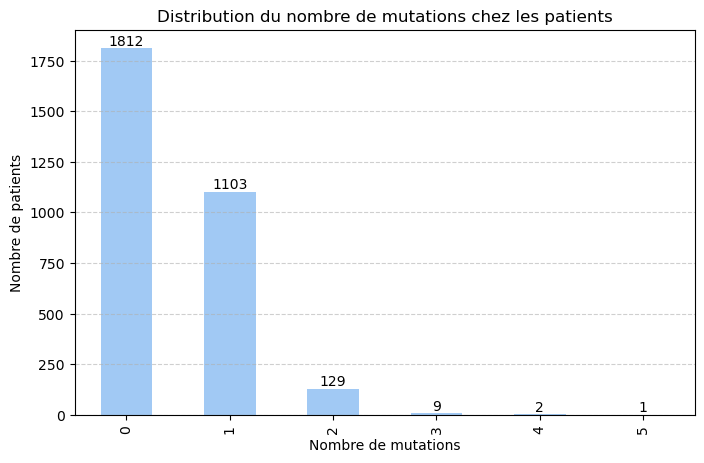

In [312]:
plt.figure(figsize=(8,5))
df_result["nombre_mutations"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution du nombre de mutations chez les patients")
plt.xlabel("Nombre de mutations")
plt.ylabel("Nombre de patients")
plt.grid(axis="y", linestyle="--", alpha=0.6)
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.show()

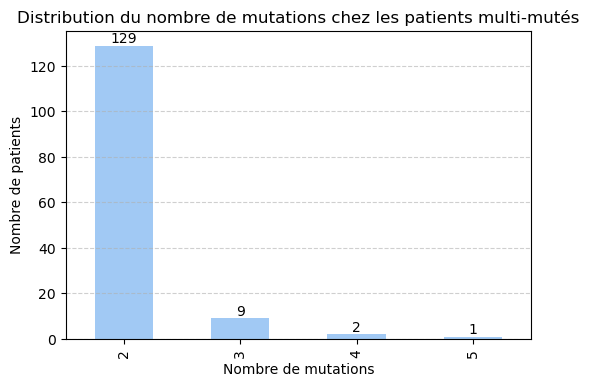

In [313]:
plt.figure(figsize=(6,4))
df_multi_mut["nombre_mutations"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution du nombre de mutations chez les patients multi-mutés")
plt.xlabel("Nombre de mutations")
plt.ylabel("Nombre de patients")
plt.grid(axis="y", linestyle="--", alpha=0.6)
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.show()


In [314]:
df_result[df_result['nombre_mutations']==1]

,NIP,Patient fumeur,date de diag,mutation,nombre_mutations,liste_mutations
3,1520329,fumeur,2015-10-22,BRAF,1,BRAF
10,1719107,fumeur,2017-11-14,TP53,1,TP53
13,1718068,fumeur,2017-11-27,BRAF,1,BRAF
17,1802509,fumeur,2018-01-16,BRAF,1,BRAF
19,1802931,ancien fumeur,2018-02-09,BRAF,1,BRAF
...,...,...,...,...,...,...
3049,2404253,fumeur,2024-02-21,TP53,1,TP53
3051,2407844,ancien fumeur,2024-04-18,BRAF,1,BRAF
3052,2408729,fumeur,2024-05-07,TP53,1,TP53
3053,2413869,ancien fumeur,2024-07-24,TP53,1,TP53


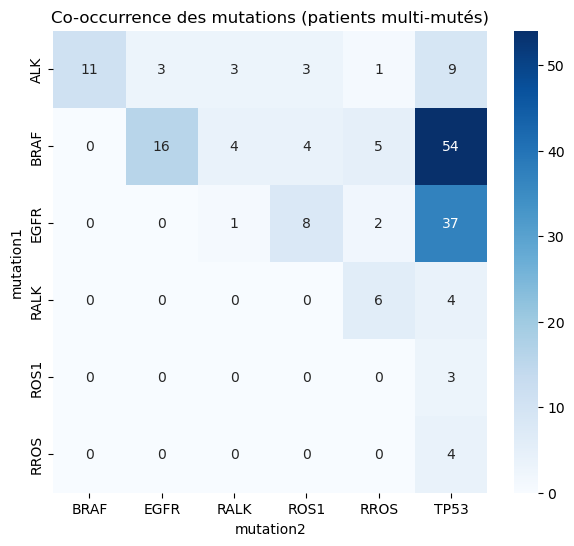

In [315]:
from itertools import combinations
from collections import Counter

# Créer toutes les paires de co-occurrence
pairs = []
for mutations in df_multi_mut["liste_mutations"]:
    muts = mutations.split(", ")
    if len(muts) > 1:
        pairs += list(combinations(sorted(muts), 2))

# Compter les co-occurrences
pair_counts = Counter(pairs)
df_pairs = pd.DataFrame(pair_counts.items(), columns=["pair", "count"])
df_pairs[["mutation1", "mutation2"]] = pd.DataFrame(df_pairs["pair"].tolist(), index=df_pairs.index)

# Pivot pour heatmap
pivot = df_pairs.pivot(index="mutation1", columns="mutation2", values="count").fillna(0)

plt.figure(figsize=(7,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Co-occurrence des mutations (patients multi-mutés)")
plt.show()


In [316]:
df_result

,NIP,Patient fumeur,date de diag,mutation,nombre_mutations,liste_mutations
0,9486811,ancien fumeur,2016-09-12,<NA>,0,Aucune
1,1616205,fumeur,2016-10-04,<NA>,0,Aucune
2,1613196,ancien fumeur,2016-07-21,<NA>,0,Aucune
3,1520329,fumeur,2015-10-22,BRAF,1,BRAF
4,787831,ancien fumeur,2007-11-15,<NA>,0,Aucune
...,...,...,...,...,...,...
3051,2407844,ancien fumeur,2024-04-18,BRAF,1,BRAF
3052,2408729,fumeur,2024-05-07,TP53,1,TP53
3053,2413869,ancien fumeur,2024-07-24,TP53,1,TP53
3054,2416892,fumeur,2024-09-04,<NA>,0,Aucune


C:\Users\lpokambo\AppData\Local\Temp\ipykernel_18976\3115163857.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_result, x='Patient fumeur', order=df_result['Patient fumeur'].value_counts().index, palette='Blues_r')


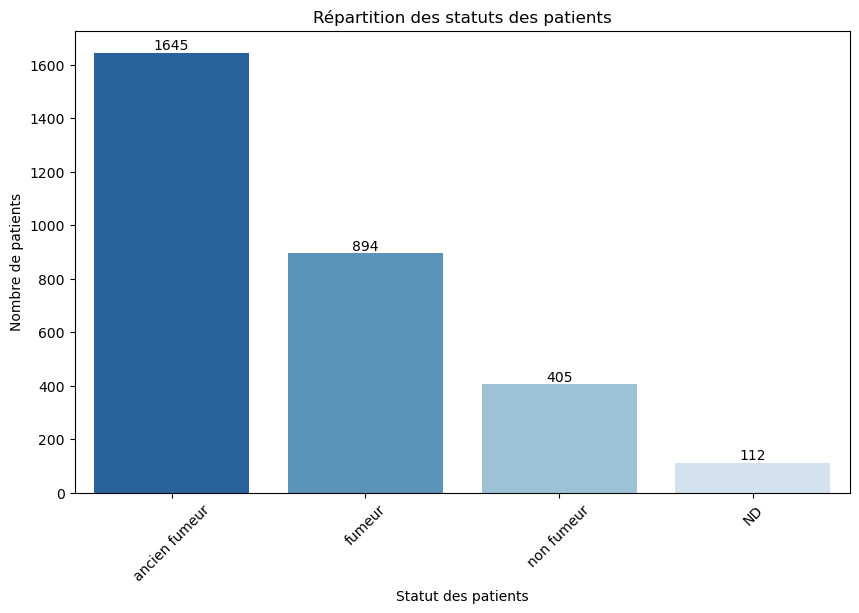

In [317]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_result, x='Patient fumeur', order=df_result['Patient fumeur'].value_counts().index, palette='Blues_r')
plt.title("Répartition des statuts des patients")
plt.xlabel("Statut des patients")
plt.ylabel("Nombre de patients")
plt.xticks(rotation=45)
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.show()

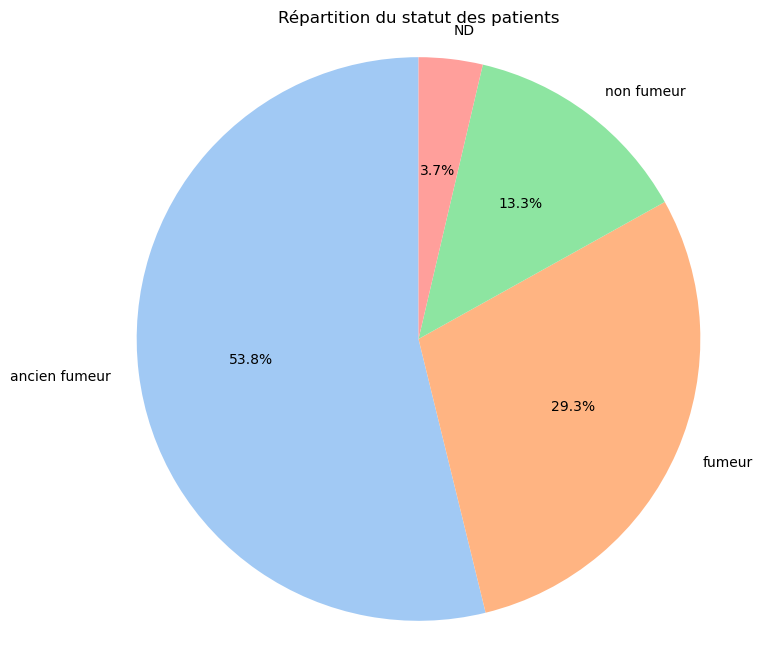

In [318]:
# diagramme en cercle du statut des patients ('fumeur, ancien fumeur, non fumeur, pas defini etc...) avec seaborn
plt.figure(figsize=(8,8))
status_counts = df_result['Patient fumeur'].value_counts()
sns.set_palette("pastel")
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Répartition du statut des patients")
plt.axis('equal')
plt.show()

<Axes: xlabel='mutation'>

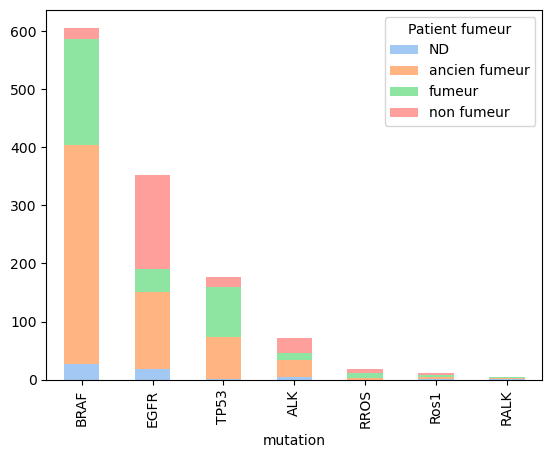

In [319]:
# Sort the crosstab rows based on the mutation value counts
mutation_order = df_result['mutation'].value_counts().index
pd.crosstab(df_result['mutation'], df_result['Patient fumeur']).loc[mutation_order].plot(kind='bar', stacked=True)

In [320]:
df_result

,NIP,Patient fumeur,date de diag,mutation,nombre_mutations,liste_mutations
0,9486811,ancien fumeur,2016-09-12,<NA>,0,Aucune
1,1616205,fumeur,2016-10-04,<NA>,0,Aucune
2,1613196,ancien fumeur,2016-07-21,<NA>,0,Aucune
3,1520329,fumeur,2015-10-22,BRAF,1,BRAF
4,787831,ancien fumeur,2007-11-15,<NA>,0,Aucune
...,...,...,...,...,...,...
3051,2407844,ancien fumeur,2024-04-18,BRAF,1,BRAF
3052,2408729,fumeur,2024-05-07,TP53,1,TP53
3053,2413869,ancien fumeur,2024-07-24,TP53,1,TP53
3054,2416892,fumeur,2024-09-04,<NA>,0,Aucune


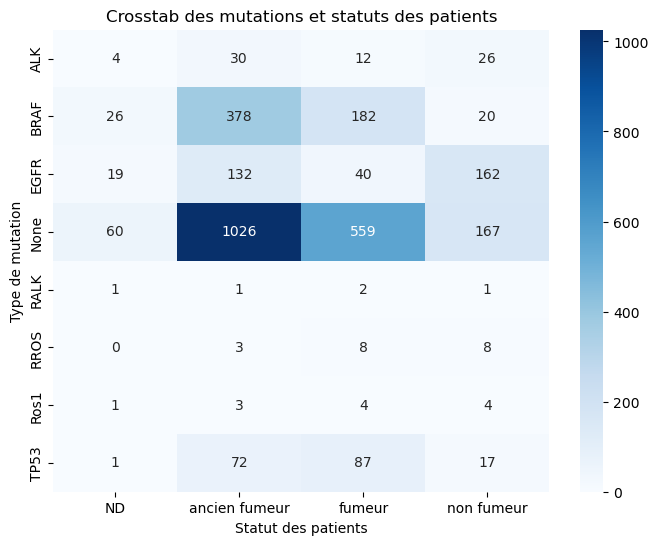

In [321]:
# je veux afficher des nombres entiers sans exponentielle
# Ne pas écraser df_result (ou tout autre DataFrame). Utiliser df_patients (DataFrame) pour le crosstab.
df_for_crosstab = df_result.copy()
df_for_crosstab['mutation'] = df_for_crosstab['mutation'].fillna('None')

crosstab = pd.crosstab(df_for_crosstab['mutation'], df_for_crosstab['Patient fumeur'])

plt.figure(figsize=(8,6))
sns.heatmap(crosstab, annot=True, cmap='Blues', fmt='d')
plt.title("Crosstab des mutations et statuts des patients")
plt.xlabel("Statut des patients")
plt.ylabel("Type de mutation")
plt.show()

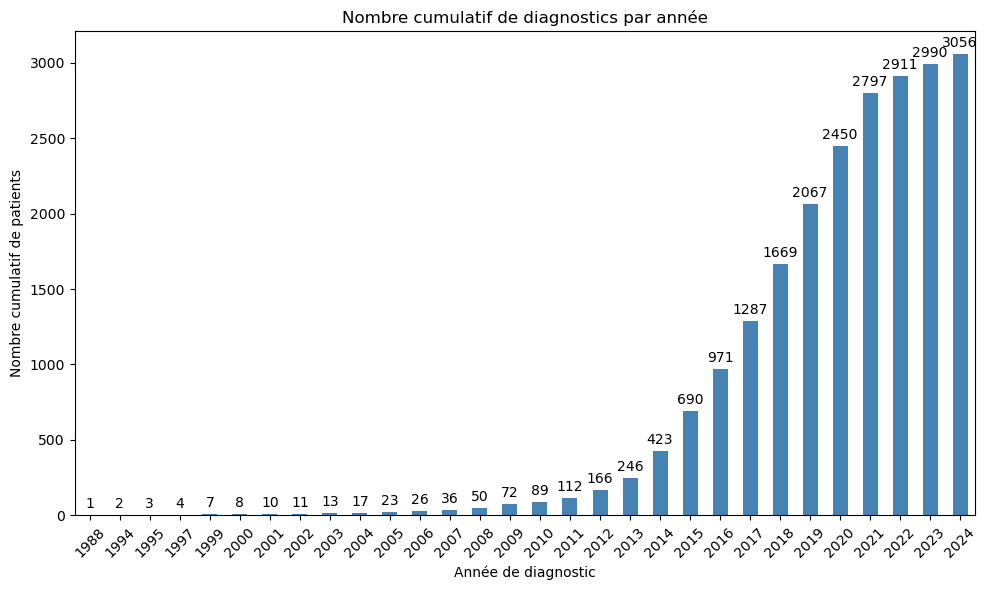

In [291]:
# je veux un barplot cumulatif en fonction de l'année de diagnostic des patients
# convertir en string puis en datetime pour éviter l'erreur liée aux objets time, forcer les erreurs en NaT
dates = pd.to_datetime(df_patients['date de diag'])
df_patients['année_diag'] = dates.dt.year

# compter les années valides, trier par année et calculer le cumul
year_counts = df_patients['année_diag'].dropna().astype(int).value_counts().sort_index()
cum_counts = year_counts.cumsum()

# tracer le barplot cumulatif
plt.figure(figsize=(10,6))
cum_counts.plot(kind='bar', color='steelblue')
plt.title("Nombre cumulatif de diagnostics par année")
plt.xlabel("Année de diagnostic")
plt.ylabel("Nombre cumulatif de patients")
plt.xticks(rotation=45)
for i, v in enumerate(cum_counts):
	plt.gca().annotate(str(int(v)), xy=(i, v), xytext=(0,5), textcoords='offset points', ha='center')
plt.tight_layout()
plt.show()

